Loaded NO-218.PRV: 31 rows
Loaded NO-220.PRV: 73 rows
Loaded NO-221.PRV: 24 rows
Loaded NO-222.PRV: 66 rows
Loaded NO-226.PRV: 43 rows
Loaded NO-305.PRV: 6 rows
Loaded NO-306.PRV: 9 rows
Loaded NO-307.PRV: 12 rows
Loaded NO-308.PRV: 24 rows
Loaded NO-312.PRV: 8 rows
Loaded SB-2041.PRV: 60 rows
Loaded SB-2001.PRV: 40 rows
Loaded SB-2003.PRV: 60 rows
Loaded SB-2007.PRV: 70 rows
Loaded SB-2008.prv: 30 rows
Loaded SB-2014.PRV: 50 rows
Loaded SB-2015.PRV: 120 rows
Loaded SB-2016.PRV: 45 rows
Loaded SB-2017.PRV: 30 rows
Loaded SB-2022.PRV: 25 rows
Loaded SB-2026.PRV: 35 rows
Loaded SB-2028.prv: 50 rows
Loaded SB-2029.prv: 50 rows
Loaded SB-2032.PRV: 45 rows
Loaded SB-2033.prv: 15 rows
Loaded SB-2037.PRV: 70 rows
Loaded SB-2040.PRV: 40 rows
Loaded NO-009.prv: 20 rows
Loaded NO-010.prv: 50 rows
Loaded NO-013.prv: 40 rows
Loaded NO-025.prv: 15 rows
Loaded NO-027.prv: 10 rows
Loaded NO-202.PRV: 11 rows
Loaded NO-208.PRV: 13 rows

Rows with gamma = 0: 1128 (will be filtered out from plot)



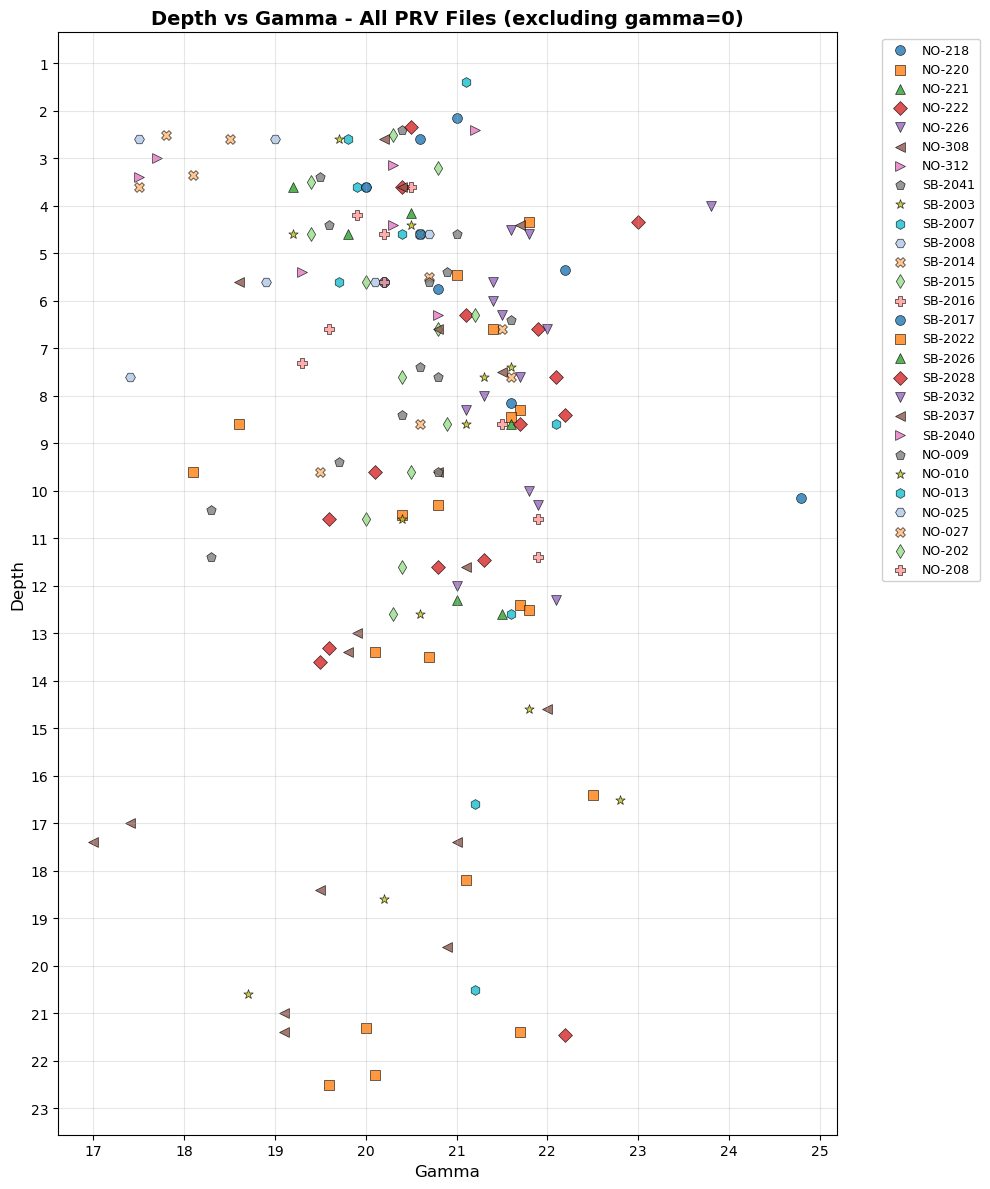

Total data points plotted: 162 (excluded 1128 zeros)


In [5]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

input_prv_path = Path(r"\\nsv2-nasuni-02\fredrikstad\Prosjekt\O10245\10245026-01\10245026-01-03_ARBEIDSOMRAADE\21_fagomraade\11_Geoteknikk\10245026-10-GEOSUITE\SB_og_NO_PRV")

def prv_to_df(prv_file: str) -> pd.DataFrame:
    data = []
    cols = ['pr_nr',
            'symb',
            'depth',
            'w',
            'wp',
            'wl',
            'suu',
            'suo',
            'sue',
            'bruddef',
            'gamma',
            'org',
            'desc']

    with open(prv_file, 'r') as f:
        lines = f.readlines()
    first_star_index = next(i for i, line in enumerate(lines) if '*' in line)

    for line in lines[first_star_index+1:]:
        if line.strip().startswith('*'):
            break
        if ' V ' in line:
            before_v, after_v = line.split(' V ', 1)
            data.append(before_v.split() + [' '.join(after_v.split())])
        else:
            split_line = line.split()
            data.append(split_line[:12] + [' '.join(split_line[12:])])
            
    df = pd.DataFrame(data, columns=cols)
    return df

# Collect all data from all prv files
all_data = []
for prv_file in input_prv_path.glob('*.prv'):
    df = prv_to_df(prv_file)
    df['file_name'] = prv_file.stem  # Add filename for reference
    all_data.append(df)
    print(f"Loaded {prv_file.name}: {len(df)} rows")

# Combine all dataframes
if all_data:
    combined_df = pd.concat(all_data, ignore_index=True)
    
    # Convert to numeric for proper filtering and plotting
    combined_df['depth'] = pd.to_numeric(combined_df['depth'], errors='coerce')
    combined_df['gamma'] = pd.to_numeric(combined_df['gamma'], errors='coerce')
    
    # Find all rows where gamma = 0
    gamma_zero = combined_df[combined_df['gamma'] == 0]
    print(f"\n{'='*60}")
    print(f"Rows with gamma = 0: {len(gamma_zero)} (will be filtered out from plot)")
    print(f"{'='*60}\n")
    
    # Filter out gamma = 0 values for plotting
    combined_df_filtered = combined_df[combined_df['gamma'] != 0].copy()
    
    # Create a single plot with all gamma values (excluding 0)
    plt.figure(figsize=(10, 12))
    
    # Define distinct marker shapes and colors
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'H', 'X', 'd', 'P']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
              '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
              '#aec7e8', '#ffbb78', '#98df8a', '#ff9896']
    
    # Plot each file with a different color and marker
    file_names = combined_df_filtered['file_name'].unique()
    for idx, file_name in enumerate(file_names):
        file_data = combined_df_filtered[combined_df_filtered['file_name'] == file_name]
        plt.scatter(file_data['gamma'], 
                   file_data['depth'], 
                   alpha=0.8,  # Increased opacity
                   label=file_name, 
                   s=50,  # Larger markers
                   marker=markers[idx % len(markers)],
                   color=colors[idx % len(colors)],
                   edgecolors='black',  # Black edge for better visibility
                   linewidths=0.5)
    
    plt.title('Depth vs Gamma - All PRV Files (excluding gamma=0)', fontsize=14, fontweight='bold')
    plt.xlabel('Gamma', fontsize=12)
    plt.ylabel('Depth', fontsize=12)
    plt.gca().invert_yaxis()  # Invert y-axis so depth increases downwards
    
    # Set major ticks to intervals of 1
    ax = plt.gca()
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_major_locator(MultipleLocator(1))
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, framealpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Total data points plotted: {len(combined_df_filtered)} (excluded {len(gamma_zero)} zeros)")
else:
    print("No PRV files found!")